### Dataset

American Sign Language (ASL) is a complete, complex language that employs signs made by moving the
hands combined with facial expressions and postures of the body. It is the primary language of many
North Americans who are deaf and is one of several communication options used by people who are deaf or
hard-of-hearing. The hand gestures representing English alphabet are shown below. This lab focuses on classifying a subset of these hand gesture images using convolutional neural networks. Specifically, given an image of a hand showing one of the letters A-I, we want to detect which letter is being represented.

![alt text](https://www.disabled-world.com/pics/1/asl-alphabet.jpg)

### Data Loading and Splitting

In [1]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

def get_asl_loaders(batch_size=32):
    
    # Define Standard Transforms
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load the full dataset
    data_dir = './data' # Update this to your local path
    full_dataset = datasets.ImageFolder(data_dir, transform=transform)
    
    # Indices and targets for stratified splitting
    indices = np.arange(len(full_dataset))
    targets = full_dataset.targets

    # First split
    train_idx, temp_idx = train_test_split(
        indices, train_size=0.7, stratify=targets, random_state=1
    )

    # Second split
    temp_targets = [targets[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, train_size=0.5, stratify=temp_targets, random_state=1
    )

    # Create Subset objects
    train_set = Subset(full_dataset, train_idx)
    val_set = Subset(full_dataset, val_idx)
    test_set = Subset(full_dataset, test_idx)

    # Create DataLoaders
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader, test_loader, len(train_idx), len(val_idx), len(test_idx), train_set

train_loader, val_loader, test_loader, n_train, n_val, n_test, train_set = get_asl_loaders()
print(f"Total: {n_train + n_val + n_test}")
print(f"Training: {n_train} | Validation: {n_val} | Test: {n_test}")

Total: 2219
Training: 1553 | Validation: 333 | Test: 333


### Model Building

#### Convolutional Network

In [2]:
import torch.nn as nn
import torch.nn.functional as F

class ASLClassifier(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.name = "ASLClassifier"
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)        
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)        
        self.conv4 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes) # num_classes = 9 (A-I)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.drop(F.relu(self.fc1(x)))
        x = self.fc2(x) # Logits
        return x

#### Training

Starting Training on cuda:0...


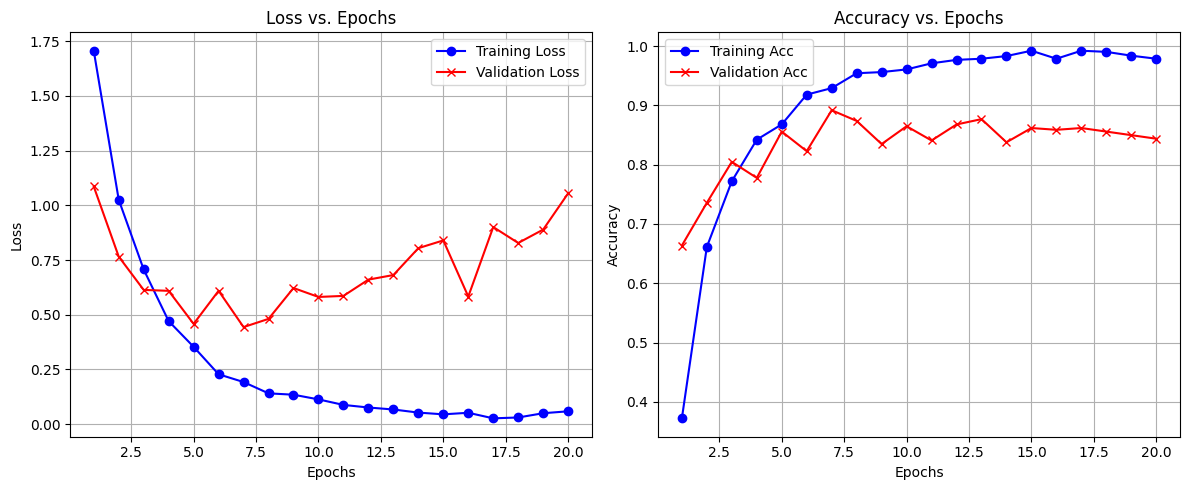

In [3]:
import matplotlib.pyplot as plt

def train(mdl, train_loader, val_loader, batch_size=32, lr=0.001, epochs=20):
    device = next(mdl.parameters()).device
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(mdl.parameters(), lr=lr)

    train_acc, val_acc = [], []
    train_loss, val_loss = [], []
    
    print(f"Starting Training on {device}...")
    
    for epoch in range(epochs):
        
        # Training Phase
        mdl.train()
        running_loss = 0
        correct = 0
        total= 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = mdl(images)
            loss = criterion(outputs, labels)

            # Backward pass
            optimizer.zero_grad()
            loss.backward() 
            optimizer.step()           

            running_loss += loss.item()
            pred = outputs.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()
            total += images.size(0)

        # Validation Phase
        mdl.eval()
        v_loss = 0.0
        v_correct = 0
        v_total = 0

        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = mdl(images)
                loss = criterion(outputs, labels)

                v_loss += loss.item()
                pred = outputs.argmax(dim=1, keepdim=True)
                v_correct += pred.eq(labels.view_as(pred)).sum().item()
                v_total += images.size(0)

        train_acc.append(correct / total)
        val_acc.append(v_correct / v_total)
        train_loss.append(running_loss / len(train_loader))
        val_loss.append(v_loss / len(val_loader))

    return train_acc, val_acc, train_loss, val_loss
    
def vizualize(train_acc, val_acc, train_loss, val_loss):
    epochs_range = range(1, len(train_acc) + 1)

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', marker='x')
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_acc, label='Training Acc', color='blue', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Acc', color='red', marker='x')
    plt.title('Accuracy vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl = ASLClassifier().to(device)
train_acc, val_acc, train_loss, val_loss = train(mdl, train_loader, val_loader)
vizualize(train_acc, val_acc, train_loss, val_loss)

### “Overfit” to a Small Dataset

One way to sanity check a neural network model and training code is to check whether the model is capable
of “overfitting” or “memorizing” a small dataset. A properly constructed CNN with correct training code
should be able to memorize the answers to a small number of images quickly.

In [4]:
import random

overfit_set = Subset(train_set, range(20))
overfit_loader = DataLoader(overfit_set, batch_size=20, shuffle=False)

mdl_tiny = ASLClassifier().to(device)

def overfit_test(mdl, loader, lr=0.001, iterations=200):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(mdl.parameters(), lr=lr)
    mdl.train()

    for i in range(iterations):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = mdl(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Calculate accuracy
            pred = outputs.argmax(dim=1, keepdim=True)
            correct = pred.eq(labels.view_as(pred)).sum().item()
            acc = correct / len(labels)
        
        if acc == 1.0:
            print(f"Reached 100% accuracy at iteration {i+1}!")
            break

# Run it
overfit_test(mdl_tiny, overfit_loader)

Reached 100% accuracy at iteration 16!


### Hyperparameter Search 

Number of filters (out_channel=), learning rate, and dropout rate

In [5]:
class ModifiedASLClassifier(nn.Module):
    def __init__(self, num_classes=9, start_filters=16, dr_rate=0.0):
        super().__init__()
        self.name = "ASLClassifier"
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=start_filters, kernel_size=3, padding=1) 
        self.conv2 = nn.Conv2d(start_filters, start_filters*2, 3, padding=1)        
        self.conv3 = nn.Conv2d(start_filters*2, start_filters*4, 3, padding=1)        
        self.conv4 = nn.Conv2d(start_filters*4, start_filters*8, 3, padding=1)
        self.fc1 = nn.Linear(start_filters*8 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes) # num_classes = 9 (A-I)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop = nn.Dropout(dr_rate)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = torch.flatten(x, 1)
        x = self.drop(F.relu(self.fc1(x)))
        x = self.fc2(x) # Logits
        return x

Starting Training on cuda:0...
Saved weights to model_checkpoints/Baseline.pt
Starting Training on cuda:0...
Saved weights to model_checkpoints/High_LR_+_Dropout.pt
Starting Training on cuda:0...
Saved weights to model_checkpoints/High_channels_+_Slow_LR_+_Dropout.pt
Starting Training on cuda:0...
Saved weights to model_checkpoints/Balanced_Regularization_+_Dropout.pt


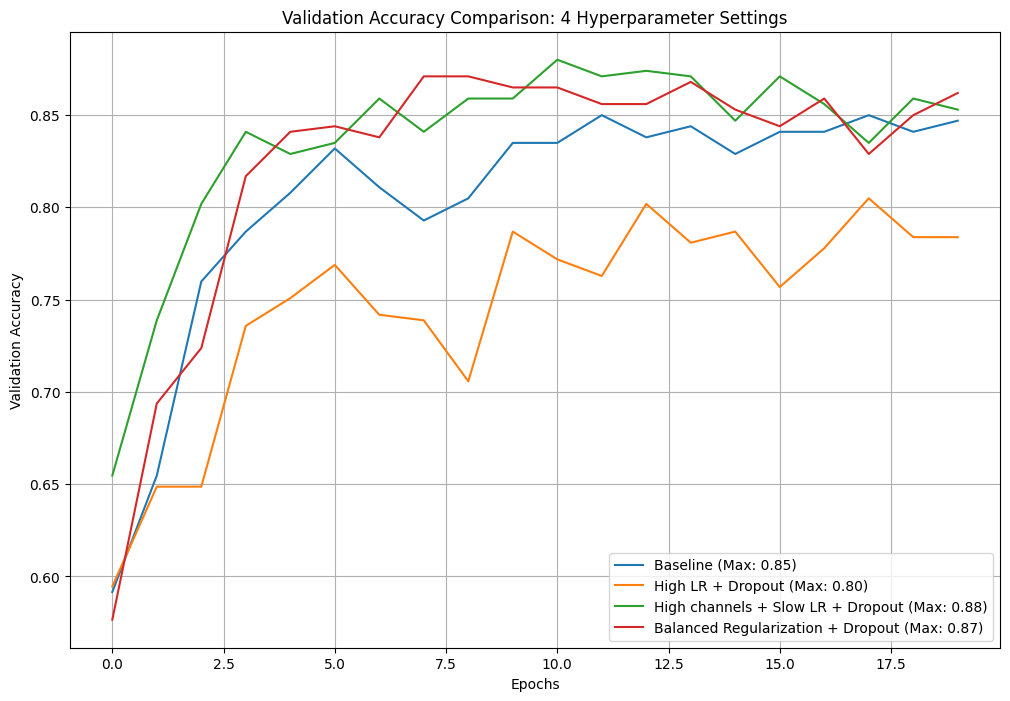

In [6]:
import os

configs = [
    {"name": "Baseline", "filters": 16, "lr": 0.001, "dropout": 0.0},
    {"name": "High LR + Dropout", "filters": 16, "lr": 0.01, "dropout": 0.5},
    {"name": "High channels + Slow LR + Dropout", "filters": 32, "lr": 0.0005, "dropout": 0.5},
    {"name": "Balanced Regularization + Dropout", "filters": 16, "lr": 0.0005, "dropout": 0.4}
]

results = {}
os.makedirs('model_checkpoints', exist_ok=True)

for config in configs:
    mdl = ModifiedASLClassifier(num_classes=9, start_filters=config['filters'], dr_rate=config['dropout']).to(device)
    
    train_acc, val_acc, train_loss, val_loss = train(mdl, train_loader, val_loader, lr=config['lr'], epochs=20 )

    model_path = f"model_checkpoints/{config['name'].replace(' ', '_')}.pt"
    torch.save(mdl.state_dict(), model_path)
    print(f"Saved weights to {model_path}")
    
    results[config['name']] = {"train_acc": train_acc, "val_acc": val_acc,"val_loss": val_loss}

plt.figure(figsize=(12, 8))

for name, data in results.items():
    plt.plot(data['val_acc'], label=f"{name} (Max: {max(data['val_acc']):.2f})")

plt.title('Validation Accuracy Comparison: 4 Hyperparameter Settings')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
config = {"name": "Baseline", "filters": 16, "lr": 0.001, "dropout": 0.0}

mdl = ModifiedASLClassifier(num_classes=9, start_filters=config['filters'], dr_rate=config['dropout']).to(device)
model_path = f"model_checkpoints/Baseline.pt"
mdl.load_state_dict(torch.load(model_path))
mdl.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        output = mdl(images)

        #select index with maximum prediction score
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += images.shape[0]

print(f"Test accuracy: {correct / total}")

C:\Users\zaher\AppData\Local\Temp\ipykernel_30468\3259713559.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mdl.load_state_dict(torch.load(model_path))


Test accuracy: 0.8708708708708709


### Transfer Learning 
For many image classification tasks, it is generally not a good idea to train a very large deep neural network
model from scratch due to the enormous compute requirements and lack of sufficient amounts of training
data.One of the better options is to try using an existing model that performs a similar task to the one you need to solve. This method of utilizing a pre-trained network for other similar tasks is broadly termed Transfer Learning.

In [8]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)

c:\Users\zaher\Documents\Code\machine-learning\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\zaher\Documents\Code\machine-learning\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


The alexnet model is split up into two components: *alexnet.features* and *alexnet.classifier*. The
first neural network component, *alexnet.features*, is used to compute convolutional features, which are
taken as input in *alexnet.classifier*.

The neural network alexnet.features expects an image tensor of shape Nx3x224x224 as input and it will
output a tensor of shape Nx256x6x6 . (N = batch size).

In [10]:
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
splits = ['train', 'val', 'test']
save_path = './AlexNet_Features'

for split in splits:
    for letter in letters:
        os.makedirs(os.path.join(save_path, split, letter), exist_ok=True)

alexnet_features = alexnet.features
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alexnet_features.to(device)
alexnet_features.eval()

def extract_and_save(dataloader, split_name):
    i = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass on AlexNet
            features = alexnet_features(images)
            
            # Move back to CPU to save to disk
            features = features.cpu()
            
            for j in range(len(images)):
                label_name = letters[labels[j]]

                # Save each image's feature map as a unique .pt file
                file_name = f"{save_path}/{split_name}/{label_name}/feat_{i}.pt"
                torch.save(features[j], file_name)
                i += 1
                
    print(f"Finished {split_name}. Saved {i} tensors.")

extract_and_save(train_loader, "train")
extract_and_save(val_loader, "val")
extract_and_save(test_loader, "test")

Finished train. Saved 1553 tensors.
Finished val. Saved 333 tensors.
Finished test. Saved 333 tensors.


In [12]:
class AlexNetASLClassifer(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()
        self.name = "AlexNetASLClassifier"
        self.fc1 = nn.Linear(256 * 6 * 6, 1024)
        self.fc2 = nn.Linear(1024, 256)
        self.fc3 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = torch.flatten(x,1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)

        return x

I chose a three layer fully connected network to act as the classifier for the features extracted by AlexNet. Since the convolutional layers in AlexNet already handled the spatial processing and pattern recognition, I only used linear layers to interpret those high level features and map them to the final nine letters. Adding additional conv layers would be a waste of computation and could make the model worse.

#### Train

Starting Training on cuda:0...


c:\Users\zaher\Documents\Code\machine-learning\.venv\Lib\site-packages\torchvision\datasets\folder.py:245: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample = self.loader

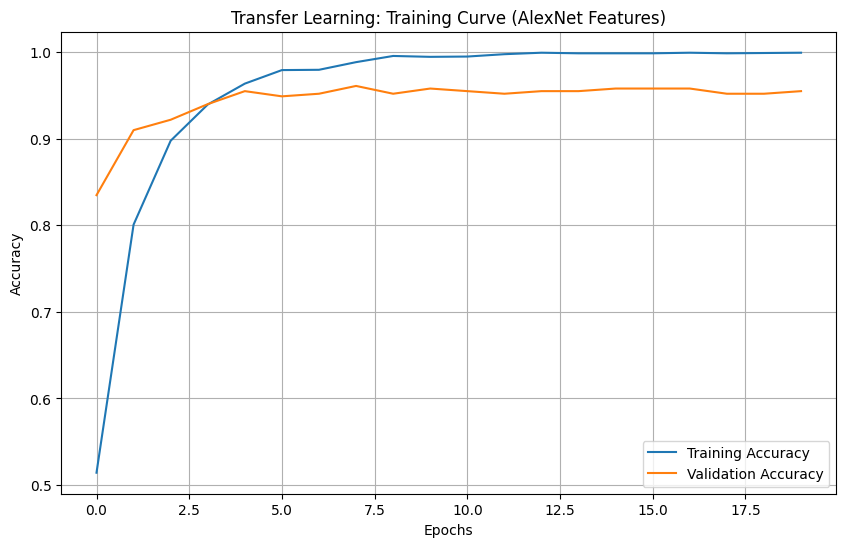

In [14]:
from torchvision.datasets import DatasetFolder

mdl = AlexNetASLClassifer().to(device)

train_features = DatasetFolder('./AlexNet_Features/train', loader=torch.load, extensions=('.pt',))
validation_features = DatasetFolder('./AlexNet_Features/val', loader=torch.load, extensions=('.pt',))
test_features = DatasetFolder('./AlexNet_Features/test', loader=torch.load, extensions=('.pt',))

train_loader = torch.utils.data.DataLoader(train_features, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(validation_features, batch_size=64, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mdl.parameters(), lr=0.0005)

train_acc, val_acc, train_loss, val_loss = train(
    mdl, train_loader, val_loader, 
    lr=0.0001, epochs=20
)

plt.figure(figsize=(10, 6))
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Transfer Learning: Training Curve (AlexNet Features)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
test_loader = torch.utils.data.DataLoader(test_features, batch_size=64, shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        output = mdl(images)

        # Select index with maximum prediction score
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += images.shape[0]

print(f"Test accuracy: {correct / total}")

Test accuracy: 0.960960960960961


The transfer learning accuracy is much better at 96% while part 3d.'s was 85%, a difference of 11%